In [109]:
import pandas as pd
import numpy as np

In [110]:
df = pd.read_csv("powerplant_data.csv")

In [111]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [113]:
# AT => Temperature
# V => Vacuum
# AP => Pressure
# RH => Humidity

# PE => Produced Energy

In [114]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [115]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [116]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
X_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [120]:
import torch
import torch.nn as nn

In [121]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [122]:
from torch.utils.data import TensorDataset, DataLoader

In [123]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [124]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Deep Learninng

In [125]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [126]:
import torch.optim as optim

model = ANN()

#losses, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [127]:
#Train th eANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total traning loss for 1 epoch

    for xb, yb in train_loader:
        #xb = feature of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop.. predictes outputs for this batch
        loss = crietrion(outputs, yb) #complete loss
        loss.backward() #back prop.. complete gradients
        optimizer.step() #parameter update

        running_loss += loss.item() #loss is a tensor => python float
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation 
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb) 
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206291.0615234375 & val loss = 205456.03125
epoch 2/100 ==> train loss = 202160.76087239583 & val loss = 195438.296875
epoch 3/100 ==> train loss = 181713.76927083332 & val loss = 164026.5
epoch 4/100 ==> train loss = 140770.1402018229 & val loss = 115216.6015625
epoch 5/100 ==> train loss = 87665.60122884114 & val loss = 62352.95703125
epoch 6/100 ==> train loss = 44743.4013671875 & val loss = 31545.447265625
epoch 7/100 ==> train loss = 25545.51639404297 & val loss = 21183.87109375
epoch 8/100 ==> train loss = 19479.883227539063 & val loss = 17371.587890625
epoch 9/100 ==> train loss = 16348.042626953125 & val loss = 14469.5302734375
epoch 10/100 ==> train loss = 13462.23524983724 & val loss = 11658.556640625
epoch 11/100 ==> train loss = 10635.74940999349 & val loss = 8987.787109375
epoch 12/100 ==> train loss = 8079.4623219807945 & val loss = 6734.0615234375
epoch 13/100 ==> train loss = 6023.6476776123045 & val loss = 4991.5068359375
epoch 14/100 ==> t

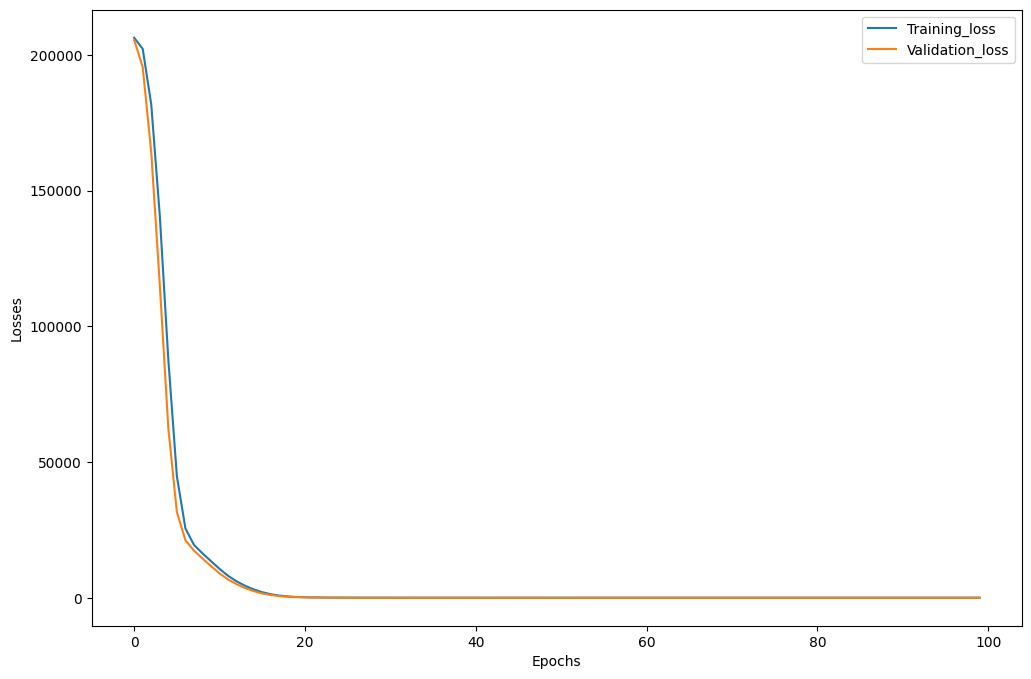

In [128]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_loss": train_losses,
    "Validation_loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training_loss"], label = "Training_loss")
plt.plot(loss_df["Validation_loss"], label = "Validation_loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()